In [2]:
import numpy as np

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [3]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [5]:
class Sequential(Module):
    """
         This class implements a container, which processes `input` data sequentially.

         `input` is processed by each module (layer) in self.modules consecutively.
         The resulting array is called `output`.
    """

    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        """
        Adds a module to the container.
        """
        self.modules.append(module)

    def updateOutput(self, input):
        """
        Basic workflow of FORWARD PASS:

            y_0    = module[0].forward(input)
            y_1    = module[1].forward(y_0)
            ...
            output = module[n-1].forward(y_{n-2})


        Just write a little loop.
        """
        current_input = input
        for module in self.modules:
            current_input = module.forward(current_input)
    
        self.output = current_input
        return self.output
    


    def backward(self, input, gradOutput):
        """
        Workflow of BACKWARD PASS:

            g_{n-1} = module[n-1].backward(y_{n-2}, gradOutput)
            g_{n-2} = module[n-2].backward(y_{n-3}, g_{n-1})
            ...
            g_1 = module[1].backward(y_0, g_2)
            gradInput = module[0].backward(input, g_1)


        !!!

        To ech module you need to provide the input, module saw while forward pass,
        it is used while computing gradients.
        Make sure that the input for `i-th` layer the output of `module[i]` (just the same input as in forward pass)
        and NOT `input` to this Sequential module.

        !!!

        """
        grad_input = gradOutput
    
        for i in range(len(self.modules) - 1, -1, -1):
            if i == 0:
                module_input = input
            else:
                module_input = self.modules[i-1].output

            grad_input = self.modules[i].backward(module_input, grad_input)
        
        self.gradInput = grad_input
        return self.gradInput


    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        """
        Should gather all parameters in a list.
        """
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        """
        Should gather all gradients w.r.t parameters in a list.
        """
        return [x.getGradParameters() for x in self.modules]

    def __repr__(self):
        string = "".join([str(x) + '\n' for x in self.modules])
        return string

    def __getitem__(self,x):
        return self.modules.__getitem__(x)

    def train(self):
        """
        Propagates training parameter through all modules
        """
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        """
        Propagates training parameter through all modules
        """
        self.training = False
        for module in self.modules:
            module.evaluate()


# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [6]:
class Linear(Module):
    """
    A module which applies a linear transformation
    A common name is fully-connected layer, InnerProductLayer in caffe.

    The module should work with 2D input of shape (n_samples, n_feature).
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        # This is a nice initialization
        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        self.output = input @ self.W.T + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput @ self.W
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradW = gradOutput.T @ input
        self.gradb = gradOutput.sum(axis = 0)

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q

## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [7]:

class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        shifted_input = input - input.max(axis=1, keepdims=True)
        exp_input = np.exp(shifted_input)
        self.output = exp_input/exp_input.sum(axis = 1, keepdims = True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        sum_prod = (gradOutput * self.output).sum(axis = 1, keepdims = True)
        self.gradInput = self.output * (gradOutput - sum_prod)
        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [8]:

class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        shifted_input = input - input.max(axis=1, keepdims=True)
        log_sum_exp = np.log(np.exp(shifted_input).sum(axis=1, keepdims=True))
        self.output = shifted_input - log_sum_exp
        return self.output

    def updateGradInput(self, input, gradOutput):
        softmax_output = np.exp(self.output)
        sum_gradOutput = gradOutput.sum(axis=1, keepdims=True)
        self.gradInput = gradOutput - softmax_output * sum_gradOutput
        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [10]:
class BatchNormalization(Module):
    EPS = 1e-3
    def __init__(self, alpha = 0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = None
        self.moving_variance = None

    def updateOutput(self, input):
        
        axes = (0, 2, 3) if input.ndim == 4 else 0
        
        if self.training:
            batch_mean = input.mean(axis=axes)
            batch_var = input.var(axis=axes)
            std = np.sqrt(batch_var + self.EPS)
            
            shape = (1, -1, 1, 1) if input.ndim == 4 else (1, -1)
            self.normalized_input = (input - batch_mean.reshape(shape)) / std.reshape(shape)
             
            if self.moving_mean is None:
                self.moving_mean = batch_mean.copy()
                self.moving_variance = batch_var.copy()
            else:
                self.moving_mean = self.alpha * self.moving_mean + (1 - self.alpha) * batch_mean
                self.moving_variance = self.alpha * self.moving_variance + (1 - self.alpha) * batch_var
            
            self.output = self.normalized_input
        else:
            std = np.sqrt(self.moving_variance + self.EPS)
            shape = (1, -1, 1, 1) if input.ndim == 4 else (1, -1)
            self.output = (input - self.moving_mean.reshape(shape)) / std.reshape(shape)
            self.normalized_input = self.output
    
        return self.output

    def updateGradInput(self, input, gradOutput):
        axes = (0, 2, 3) if input.ndim == 4 else 0
        
        if self.training:
            batch_mean = input.mean(axis=axes)
            batch_var = input.var(axis=axes)
            std = np.sqrt(batch_var + self.EPS)
            shape = (1, -1, 1, 1) if input.ndim == 4 else (1, -1)
            normalized_input = (input - batch_mean.reshape(shape)) / std.reshape(shape)
        else:
            std = np.sqrt(self.moving_variance + self.EPS)
            shape = (1, -1, 1, 1) if input.ndim == 4 else (1, -1)
            normalized_input = (input - self.moving_mean.reshape(shape)) / std.reshape(shape)
        
        N = input.shape[0] * (input.shape[2] * input.shape[3] if input.ndim == 4 else 1)
        
        sum_gradOutput = gradOutput.sum(axis=axes)
        sum_grad_dot_norm = (gradOutput * normalized_input).sum(axis=axes)
        
        factor = (1. / (N * std.reshape((1,-1,1,1) if input.ndim==4 else (1,-1))))
        norm_shape = (1, -1, 1, 1) if input.ndim == 4 else (1, -1)
        
        term1 = N * gradOutput
        term2 = sum_gradOutput.reshape(norm_shape)
        term3 = normalized_input * sum_grad_dot_norm.reshape(norm_shape)
        
        self.gradInput = factor * (term1 - term2 - term3)
        
        return self.gradInput

    def __repr__(self):
        return "BatchNormalization"
    

In [11]:
class ChannelwiseScaling(Module):
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()
        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)
        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        if input.ndim == 4:
            g = self.gamma.reshape(1, -1, 1, 1)
            b = self.beta.reshape(1, -1, 1, 1)
        else:
            g = self.gamma
            b = self.beta
            
        self.output = input * g + b
        return self.output

    def updateGradInput(self, input, gradOutput):
        if input.ndim == 4:
            g = self.gamma.reshape(1, -1, 1, 1)
        else:
            g = self.gamma
        self.gradInput = gradOutput * g
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        if input.ndim == 4:
            self.gradBeta = np.sum(gradOutput, axis=(0, 2, 3))
            self.gradGamma = np.sum(gradOutput * input, axis=(0, 2, 3)) 
        else:
            self.gradBeta = np.sum(gradOutput, axis=0)
            self.gradGamma = np.sum(gradOutput * input, axis=0)
            
    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [12]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        if self.training:
            self.mask = np.random.binomial(1, 1 - self.p, size=input.shape)
            self.output = input * self.mask / (1 - self.p)
        else:
            self.output = input
        return self.output

    def updateGradInput(self, input, gradOutput):
        if self.training:
            self.gradInput = gradOutput * self.mask / (1 - self.p)
        else:
            self.gradInput = gradOutput
        return self.gradInput

    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride, padding, bias, padding_mode) and fix dilation=1 and groups=1.

In [13]:
class Conv2d(Module):
    """
    2D Convolution layer implemented with explicit loops.
    Parameters:
        in_channels: number of input channels
        out_channels: number of output channels
        kernel_size: int or tuple (Kh, Kw)
        stride: int or tuple (Sh, Sw), default 1
        padding: int, tuple, or 'same'
        bias: bool, whether to use learnable bias
        padding_mode: only 'zeros' supported
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True, padding_mode='zeros'):
        super(Conv2d, self).__init__()
        
        if isinstance(kernel_size, int):
            self.kernel_size = (kernel_size, kernel_size)
        else:
            self.kernel_size = kernel_size
            
        if isinstance(stride, int):
            self.stride = (stride, stride)
        else:
            self.stride = stride
            
        if padding == 'same':
            if self.stride[0] == 1 and self.stride[1] == 1:
                self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)
            else:
                self.padding = 'same'
        elif isinstance(padding, int):
            self.padding = (padding, padding)
        else:
            self.padding = padding
            
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.bias_flag = bias
        self.padding_mode = padding_mode
        
        stdv = 1. / np.sqrt(in_channels * self.kernel_size[0] * self.kernel_size[1])
        self.weight = np.random.uniform(-stdv, stdv, size=(out_channels, in_channels, *self.kernel_size))
        
        if bias:
            self.bias = np.random.uniform(-stdv, stdv, size=out_channels)
            self.gradBias = np.zeros_like(self.bias)
        else:
            self.bias = None
            
        self.gradWeight = np.zeros_like(self.weight)
        
        self._padded_input = None
        self._input_shape = None
        
    def _compute_output_size(self, H_in, W_in):
        Kh, Kw = self.kernel_size
        Sh, Sw = self.stride
        
        if self.padding == 'same':
            pad_h = (Kh - 1) // 2
            pad_w = (Kw - 1) // 2
        else:
            pad_h, pad_w = self.padding
            
        H_out = (H_in + 2 * pad_h - Kh) // Sh + 1
        W_out = (H_in + 2 * pad_w - Kw) // Sw + 1
        return H_out, W_out, pad_h, pad_w
    
    def updateOutput(self, input):
        """
        Forward pass: input shape (B, C_in, H_in, W_in)
        Output shape: (B, C_out, H_out, W_out)
        """
        B, C_in, H_in, W_in = input.shape
        Kh, Kw = self.kernel_size
        Sh, Sw = self.stride
        
        H_out, W_out, pad_h, pad_w = self._compute_output_size(H_in, W_in)
        
        if pad_h > 0 or pad_w > 0:
            self._padded_input = np.pad(input, 
                                        ((0, 0), (0, 0), (pad_h, pad_h), (pad_w, pad_w)), 
                                        mode='constant', constant_values=0)
        else:
            self._padded_input = input
            
        self._input_shape = (B, C_in, H_in, W_in)
        self._pad_h, self._pad_w = pad_h, pad_w
        
        self.output = np.zeros((B, self.out_channels, H_out, W_out))
        
        for b in range(B):
            for out_c in range(self.out_channels):
                for i in range(H_out):
                    for j in range(W_out):
                        # Координаты окна в padded input
                        h_start = i * Sh
                        w_start = j * Sw
                        h_end = h_start + Kh
                        w_end = w_start + Kw
                        
                        # Извлекаем патч: (C_in, Kh, Kw)
                        patch = self._padded_input[b, :, h_start:h_end, w_start:w_end]
                        
                        # Свёртка: сумма по всем каналам и ядру
                        val = np.sum(patch * self.weight[out_c])
                        
                        if self.bias_flag:
                            val += self.bias[out_c]
                            
                        self.output[b, out_c, i, j] = val
                        
        return self.output
    
    def updateGradInput(self, input, gradOutput):
        """
        Backward pass: вычисление градиента по входу.
        gradOutput: (B, C_out, H_out, W_out)
        gradInput: (B, C_in, H_in, W_in)
        """
        B, C_in, H_in, W_in = self._input_shape
        Kh, Kw = self.kernel_size
        Sh, Sw = self.stride
        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]
        pad_h, pad_w = self._pad_h, self._pad_w
        
        # Инициализируем градиент по padded входу
        grad_padded = np.zeros((B, C_in, H_in + 2*pad_h, W_in + 2*pad_w))
        
        # Распределяем градиент через "полную свёртку"
        for b in range(B):
            for in_c in range(C_in):
                for out_c in range(self.out_channels):
                    for i in range(H_out):
                        for j in range(W_out):
                            h_start = i * Sh
                            w_start = j * Sw
                            
                            # Градиент умножается на соответствующие веса ядра
                            for ki in range(Kh):
                                for kj in range(Kw):
                                    grad_padded[b, in_c, h_start + ki, w_start + kj] += \
                                        gradOutput[b, out_c, i, j] * self.weight[out_c, in_c, ki, kj]
        
        if pad_h > 0 or pad_w > 0:
            self.gradInput = grad_padded[:, :, pad_h:pad_h+H_in, pad_w:pad_w+W_in]
        else:
            self.gradInput = grad_padded
            
        return self.gradInput
    
    def accGradParameters(self, input, gradOutput):
        """
        Вычисление градиентов по параметрам (весам и смещению).
        """
        B, C_in, H_in, W_in = self._input_shape
        Kh, Kw = self.kernel_size
        Sh, Sw = self.stride
        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]
        pad_h, pad_w = self._pad_h, self._pad_w
        
        # Градиент по весам: свёртка input с gradOutput
        self.gradWeight.fill(0)
        
        for b in range(B):
            for out_c in range(self.out_channels):
                for in_c in range(C_in):
                    for i in range(H_out):
                        for j in range(W_out):
                            h_start = i * Sh
                            w_start = j * Sw
                            
                            for ki in range(Kh):
                                for kj in range(Kw):
                                    self.gradWeight[out_c, in_c, ki, kj] += \
                                        gradOutput[b, out_c, i, j] * self._padded_input[b, in_c, h_start + ki, w_start + kj]
        
        if self.bias_flag:
            self.gradBias = np.sum(gradOutput, axis=(0, 2, 3))
    
    def zeroGradParameters(self):
        self.gradWeight.fill(0)
        if self.bias_flag:
            self.gradBias.fill(0)
    
    def getParameters(self):
        if self.bias_flag:
            return [self.weight, self.bias]
        return [self.weight]
    
    def getGradParameters(self):
        if self.bias_flag:
            return [self.gradWeight, self.gradBias]
        return [self.gradWeight]
    
    def __repr__(self):
        Kh, Kw = self.kernel_size
        Sh, Sw = self.stride
        s = f"Conv2d({self.in_channels}->{self.out_channels}, kernel={Kh}x{Kw}, stride=({Sh},{Sw}))"
        return s

#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [14]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride=None, padding=0):
        super(MaxPool2d, self).__init__()
        
        if isinstance(kernel_size, int):
            self.kernel_size = (kernel_size, kernel_size)
        else:
            self.kernel_size = kernel_size
            
        if stride is None:
            self.stride = self.kernel_size
        elif isinstance(stride, int):
            self.stride = (stride, stride)
        else:
            self.stride = stride
            
        self.padding = padding
        
        self.max_indices = None
        
    def updateOutput(self, input):
        B, C, H_in, W_in = input.shape
        K_h, K_w = self.kernel_size 
        S_h, S_w = self.stride
        
        H_out = (H_in + 2 * self.padding - K_h) // S_h + 1
        W_out = (W_in + 2 * self.padding - K_w) // S_w + 1
        
        if self.padding > 0:
            padded_input = np.pad(input, 
                                  ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)), 
                                  mode='constant', constant_values=-np.inf)
        else:
            padded_input = input
        
        self.output = np.zeros((B, C, H_out, W_out))
        self.max_indices = np.zeros((B, C, H_out, W_out), dtype=int)
        
        for b in range(B):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * S_h
                        w_start = j * S_w
                        h_end = h_start + K_h
                        w_end = w_start + K_w
                        
                        patch = padded_input[b, c, h_start:h_end, w_start:w_end]
                        
                        flat_patch = patch.flatten()
                        max_idx = np.argmax(flat_patch)
                        
                        self.output[b, c, i, j] = flat_patch[max_idx]
                        self.max_indices[b, c, i, j] = max_idx
        
        self._input_shape = (B, C, H_in, W_in)
        
        return self.output
    
    def updateGradInput(self, input, gradOutput):
        B, C, H_in, W_in = self._input_shape
        K_h, K_w = self.kernel_size
        S_h, S_w = self.stride
        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]
        
        grad_padded = np.zeros((B, C, H_in + 2*self.padding, W_in + 2*self.padding))
        
        for b in range(B):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * S_h
                        w_start = j * S_w
                        
                        max_idx = self.max_indices[b, c, i, j]
                        
                        di = max_idx // K_w
                        dj = max_idx % K_w
                        
                        grad_padded[b, c, h_start + di, w_start + dj] += gradOutput[b, c, i, j]
        
        if self.padding > 0:
            self.gradInput = grad_padded[:, :, 
                                         self.padding:self.padding+H_in, 
                                         self.padding:self.padding+W_in]
        else:
            self.gradInput = grad_padded
        
        return self.gradInput

    def __repr__(self):
        return "MaxPool2d"

class AvgPool2d(Module):
    def __init__(self, kernel_size, stride=None, padding=0):
        super(AvgPool2d, self).__init__()
        
        if isinstance(kernel_size, int):
            self.kernel_size = (kernel_size, kernel_size)
        else:
            self.kernel_size = kernel_size
            
        if stride is None:
            self.stride = self.kernel_size
        elif isinstance(stride, int):
            self.stride = (stride, stride)
        else:
            self.stride = stride
            
        self.padding = padding
        
    def updateOutput(self, input):
        B, C, H_in, W_in = input.shape
        K_h, K_w = self.kernel_size
        S_h, S_w = self.stride
        
        H_out = (H_in + 2 * self.padding - K_h) // S_h + 1
        W_out = (W_in + 2 * self.padding - K_w) // S_w + 1
        
        if self.padding > 0:
            padded_input = np.pad(input, 
                                  ((0, 0), (0, 0), (self.padding, self.padding), (self.padding, self.padding)), 
                                  mode='constant', constant_values=0)
        else:
            padded_input = input
        
        self.output = np.zeros((B, C, H_out, W_out))
        kernel_area = K_h * K_w
        
        for b in range(B):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * S_h
                        w_start = j * S_w
                        h_end = h_start + K_h
                        w_end = w_start + K_w
                        
                        patch = padded_input[b, c, h_start:h_end, w_start:w_end]
                        self.output[b, c, i, j] = np.mean(patch)
        
        self._padded_input = padded_input
        self._input_shape = (B, C, H_in, W_in)
        self._kernel_area = kernel_area
        
        return self.output
    
    def updateGradInput(self, input, gradOutput):
        B, C, H_in, W_in = self._input_shape
        K_h, K_w = self.kernel_size
        S_h, S_w = self.stride
        H_out, W_out = gradOutput.shape[2], gradOutput.shape[3]
        kernel_area = self._kernel_area
        
        grad_padded = np.zeros((B, C, H_in + 2*self.padding, W_in + 2*self.padding))
        
        for b in range(B):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start = i * S_h
                        w_start = j * S_w
                        
                        grad_to_distribute = gradOutput[b, c, i, j] / kernel_area
                        
                        grad_padded[b, c, 
                                  h_start:h_start+K_h, 
                                  w_start:w_start+K_w] += grad_to_distribute
        
        if self.padding > 0:
            self.gradInput = grad_padded[:, :, 
                                         self.padding:self.padding+H_in, 
                                         self.padding:self.padding+W_in]
        else:
            self.gradInput = grad_padded
        
        return self.gradInput

    def __repr__(self):
        return "AvgPool2d"

#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

In [15]:
class GlobalMaxPool2d(Module):
    def __init__(self):
        super(GlobalMaxPool2d, self).__init__()
        self.max_indices = None  
        
    def updateOutput(self, input):
        B, C, H, W = input.shape
        
        input_flat = input.reshape(B, C, -1)  
        
        self.output = np.max(input_flat, axis=2, keepdims=True)  
        self.max_indices = np.argmax(input_flat, axis=2)  
        
        self.output = self.output.reshape(B, C, 1, 1)
        
        self._input_shape = (B, C, H, W)
        
        return self.output
    
    def updateGradInput(self, input, gradOutput):
        B, C, H, W = self._input_shape
        
        self.gradInput = np.zeros((B, C, H, W))
        
        for b in range(B):
            for c in range(C):
                max_idx = self.max_indices[b, c]
                
                h_idx = max_idx // W
                w_idx = max_idx % W
                
                self.gradInput[b, c, h_idx, w_idx] += gradOutput[b, c, 0, 0]
        
        return self.gradInput
    
    def __repr__(self):
        return "GlobalMaxPool2d"
    
class GlobalAvgPool2d(Module):
    """
    Global Average Pooling: агрегирует среднее по всему пространству (H×W) для каждого канала.
    Вход:  (B, C, H, W)
    Выход: (B, C, 1, 1)
    """
    def __init__(self):
        super(GlobalAvgPool2d, self).__init__()
        
    def updateOutput(self, input):
        B, C, H, W = input.shape
        
        self.output = np.mean(input, axis=(2, 3), keepdims=True)  # (B, C, 1, 1)
        
        self._input_shape = (B, C, H, W)
        self._spatial_size = H * W
        
        return self.output
    
    def updateGradInput(self, input, gradOutput):
        B, C, H, W = self._input_shape
        spatial_size = self._spatial_size
        
        self.gradInput = gradOutput / spatial_size  
        
        return self.gradInput
    
    def __repr__(self):
        return "GlobalAvgPool2d"

#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [16]:
class Flatten(Module):
    def __init__(self, start_dim=0, end_dim=-1):
        super(Flatten, self).__init__()
        self.start_dim = start_dim
        self.end_dim = end_dim
        
    def updateOutput(self, input):
        self._input_shape = input.shape
        
        ndim = input.ndim
        start = self.start_dim if self.start_dim >= 0 else ndim + self.start_dim
        end = self.end_dim if self.end_dim >= 0 else ndim + self.end_dim
        
        shape_before = input.shape[:start]
        shape_after = input.shape[end+1:] if end + 1 < ndim else ()
        new_shape = shape_before + (-1,) + shape_after
        
        self.output = input.reshape(new_shape)
        
        return self.output
    
    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(self._input_shape)
        return self.gradInput

    def __repr__(self):
        return "Flatten"

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [17]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [18]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        self.output = np.maximum(input, self.slope * input)
        return self.output

    def updateGradInput(self, input, gradOutput):
        mask = input > 0
        self.gradInput = gradOutput * (mask + ~mask * self.slope)
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [19]:

class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        self.output = np.where(input > 0, input, self.alpha * (np.exp(input) - 1))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        mask = input > 0
        grad_factor = np.where(mask, 1.0, self.output + self.alpha)
        self.gradInput = gradOutput * grad_factor
        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [20]:

class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0) + np.log1p(np.exp(-np.abs(input)))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        exp_neg_x = np.exp(-np.abs(input))
        sigmoid = np.where(input >= 0, 
                          1 / (1 + exp_neg_x), 
                          exp_neg_x / (1 + exp_neg_x))
        self.gradInput = gradOutput * sigmoid
        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

In [21]:
import math

class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
        erf_vec = np.vectorize(math.erf)
        self.output = 0.5 * input * (1.0 + erf_vec(input / np.sqrt(2.0)))
        return self.output

    def updateGradInput(self, input, gradOutput):
        erf_vec = np.vectorize(math.erf)
        deriv = 0.5 * (1.0 + erf_vec(input / np.sqrt(2.0))) + \
                input * np.exp(-input ** 2 / 2.0) / np.sqrt(2.0 * np.pi)
        self.gradInput = gradOutput * deriv
        return self.gradInput

    def __repr__(self):
        return "Gelu"

# Criterions

Criterions are used to score the models answers.

In [22]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [23]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [24]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15

    def __init__(self):
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        batch_size = input.shape[0]
        self.output = -np.sum(target * np.log(input_clamp)) / batch_size
        return self.output

    def updateGradInput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        batch_size = input.shape[0]
        self.gradInput = -target / input_clamp / batch_size
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [25]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        batch_size = input.shape[0]
        self.output = -np.sum(target * input) / batch_size
        return self.output

    def updateGradInput(self, input, target):
        batch_size = input.shape[0]
        self.gradInput = -target / batch_size
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.
6. Свитч лося (метрики) и оптимайзера.

Реализуем оптимизатор \
В силу разнообразия задач, использования batchnorm + dropout и относительной простоты реализации, возьмем Adam

In [26]:
class Adam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.lr = lr
        self.betas = betas          
        self.eps = eps              
        self.t = 0                  
        
        self.params = params
        
        self.m = [[np.zeros_like(p) for p in group] for group in params]
        self.v = [[np.zeros_like(p) for p in group] for group in params]

    def step(self, grads):
        self.t += 1
        beta1, beta2 = self.betas
        
        for i, (param_group, grad_group) in enumerate(zip(self.params, grads)):
            for j, (p, g) in enumerate(zip(param_group, grad_group)):
                self.m[i][j] = beta1 * self.m[i][j] + (1 - beta1) * g
                self.v[i][j] = beta2 * self.v[i][j] + (1 - beta2) * (g ** 2)
                
                m_hat = self.m[i][j] / (1 - beta1 ** self.t)
                v_hat = self.v[i][j] / (1 - beta2 ** self.t)
                
                p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

Реализуем мультирегрессию

In [ ]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


 Training SMALL model with ReLU
Epoch 10 | Train: 0.8517 | Val: 0.6394 | LR: 8.15e-04
Epoch 20 | Train: 0.2141 | Val: 0.0730 | LR: 4.88e-04
Epoch 30 | Train: 0.1801 | Val: 0.0567 | LR: 2.92e-04
Epoch 40 | Train: 0.2034 | Val: 0.0545 | LR: 1.75e-04
Final Test MSE: 0.0531


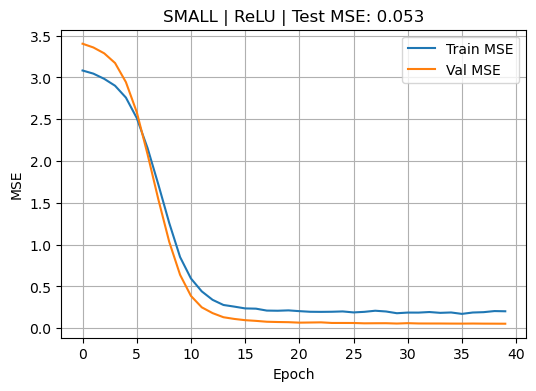


 Training MEDIUM model with ReLU
Epoch 10 | Train: 0.2454 | Val: 0.0444 | LR: 8.15e-04
Epoch 20 | Train: 0.2177 | Val: 0.0275 | LR: 4.88e-04
Epoch 30 | Train: 0.2017 | Val: 0.0246 | LR: 2.92e-04
Early stop at epoch 34
Final Test MSE: 0.0282


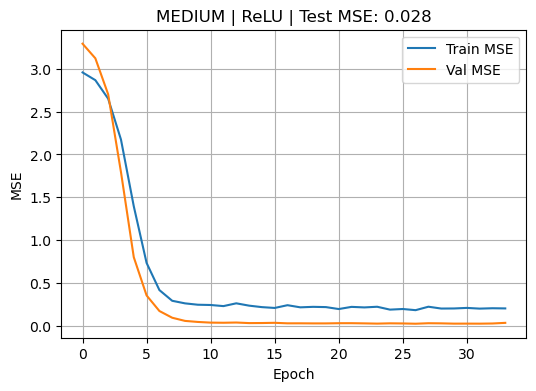


 Training LARGE model with ReLU
Epoch 10 | Train: 0.2319 | Val: 0.0440 | LR: 8.15e-04
Epoch 20 | Train: 0.2251 | Val: 0.0318 | LR: 4.88e-04
Early stop at epoch 28
Final Test MSE: 0.0250


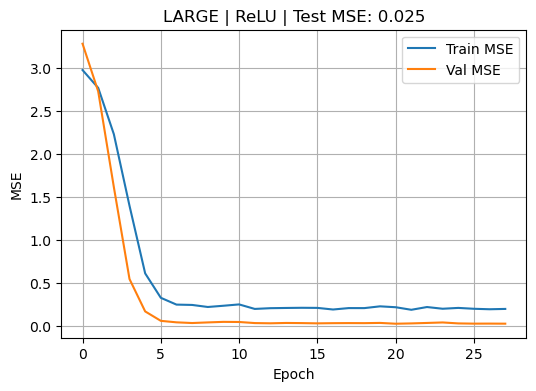


 Training SMALL model with Gelu
Epoch 10 | Train: 0.6451 | Val: 0.4647 | LR: 8.15e-04
Epoch 20 | Train: 0.1313 | Val: 0.0298 | LR: 4.88e-04
Epoch 30 | Train: 0.1112 | Val: 0.0224 | LR: 2.92e-04
Epoch 40 | Train: 0.1280 | Val: 0.0249 | LR: 1.75e-04
Final Test MSE: 0.0224


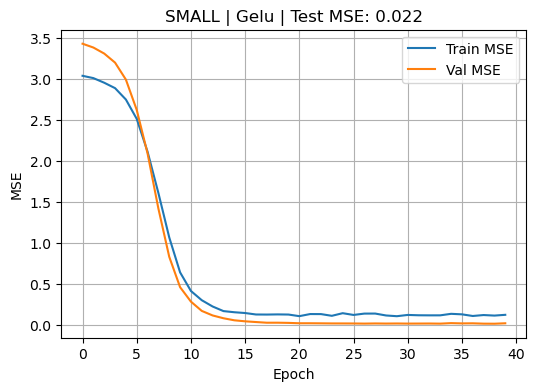


 Training MEDIUM model with Gelu
Epoch 10 | Train: 0.1512 | Val: 0.0300 | LR: 8.15e-04
Epoch 20 | Train: 0.1420 | Val: 0.0207 | LR: 4.88e-04
Epoch 30 | Train: 0.1310 | Val: 0.0178 | LR: 2.92e-04
Epoch 40 | Train: 0.1263 | Val: 0.0180 | LR: 1.75e-04
Final Test MSE: 0.0167


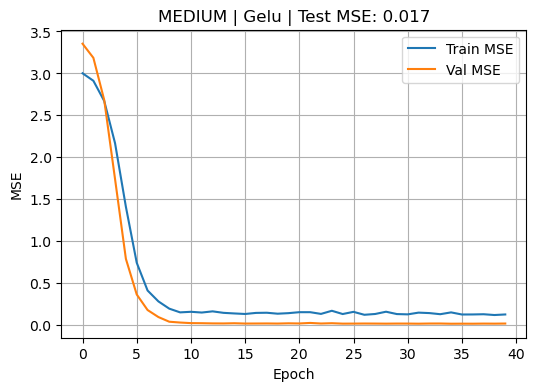


 Training LARGE model with Gelu
Epoch 10 | Train: 0.1694 | Val: 0.0330 | LR: 8.15e-04
Epoch 20 | Train: 0.1375 | Val: 0.0172 | LR: 4.88e-04
Early stop at epoch 30
Final Test MSE: 0.0205


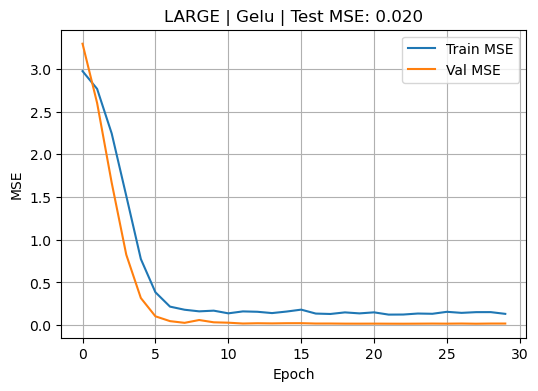


 Training SMALL model with ELU
Epoch 10 | Train: 0.4418 | Val: 0.3017 | LR: 8.15e-04
Epoch 20 | Train: 0.1397 | Val: 0.0217 | LR: 4.88e-04
Early stop at epoch 30
Final Test MSE: 0.0227


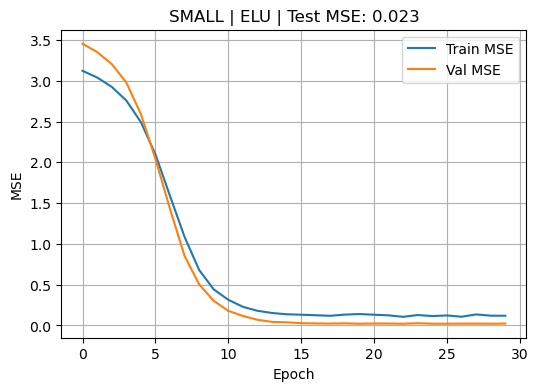


 Training MEDIUM model with ELU
Epoch 10 | Train: 0.1709 | Val: 0.0206 | LR: 8.15e-04
Epoch 20 | Train: 0.1512 | Val: 0.0213 | LR: 4.88e-04
Early stop at epoch 28
Final Test MSE: 0.0239


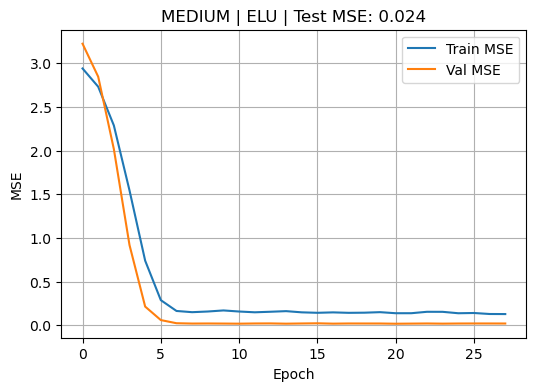


 Training LARGE model with ELU
Epoch 10 | Train: 0.1879 | Val: 0.0289 | LR: 8.15e-04
Epoch 20 | Train: 0.1519 | Val: 0.0219 | LR: 4.88e-04
Early stop at epoch 23
Final Test MSE: 0.0474


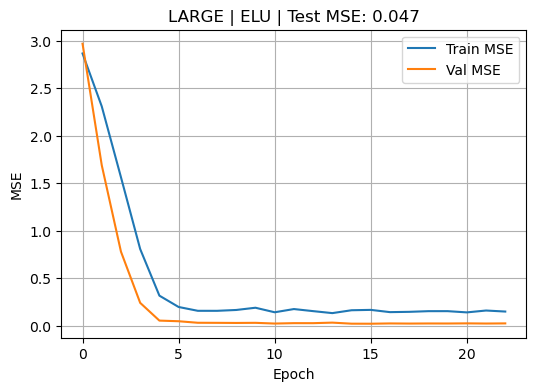

In [ ]:
# Подготовим данные и выборки
X, y = make_regression(n_samples=2000, n_features=8, n_targets=3, noise=10.0, random_state=42)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

#Стандартизируем
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)
X_train, X_val, X_test = scaler_X.transform(X_train), scaler_X.transform(X_val), scaler_X.transform(X_test)
y_train, y_val, y_test = scaler_y.transform(y_train), scaler_y.transform(y_val), scaler_y.transform(y_test)

# Функция для генерации моделей разного размера
def build_regression_model(size, activation_cls, n_features=8, n_targets=3):
    model = Sequential()
    if size == 'small':
        model.add(Linear(n_features, 32))
        model.add(BatchNormalization(alpha=0.9))
        model.add(ChannelwiseScaling(32))
        model.add(activation_cls())
        model.add(Dropout(0.1))
        
    elif size == 'medium':
        model.add(Linear(n_features, 128))
        model.add(BatchNormalization(alpha=0.9))
        model.add(ChannelwiseScaling(128))
        model.add(activation_cls())
        model.add(Dropout(0.2))
        
        model.add(Linear(128, 64))
        model.add(BatchNormalization(alpha=0.9))
        model.add(ChannelwiseScaling(64))
        model.add(activation_cls())
        model.add(Dropout(0.2))
        
    elif size == 'large':
        for units in [512, 256, 128]:
            model.add(Linear(n_features if units==512 else units*2, units))
            model.add(BatchNormalization(alpha=0.9))
            model.add(ChannelwiseScaling(units))
            model.add(activation_cls())
            model.add(Dropout(0.3))
            n_features = units
            
    model.add(Linear(n_features if size=='large' else (64 if size=='medium' else 32), n_targets))
    return model

# Обучение и сравнение
def train_and_evaluate(size, activation_cls, epochs=50, batch_size=32):
    print(f"\n Training {size.upper()} model with {repr(activation_cls())}")
    
    model = build_regression_model(size, activation_cls)
    criterion = MSECriterion()
    optimizer = Adam(model.getParameters(), lr=1e-3, betas=(0.9, 0.999))
    
    train_losses, val_losses = [], []
    best_val_loss = np.inf
    best_weights = None
    patience = 7
    no_improve = 0
    warmup_epochs = 5
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        # Мини-батчи
        idx = np.random.permutation(len(X_train))
        for start in range(0, len(X_train), batch_size):
            end = min(start + batch_size, len(X_train))
            x_batch = X_train[idx[start:end]]
            y_batch = y_train[idx[start:end]]
            
            # Warmup + Decay
            if epoch < warmup_epochs:
                optimizer.lr = 1e-3 * (epoch + 1) / warmup_epochs
            else:
                optimizer.lr = 1e-3 * (0.95 ** (epoch - warmup_epochs))
                
            model.zeroGradParameters()
            pred = model.forward(x_batch)
            loss = criterion.forward(pred, y_batch)
            grad = criterion.backward(pred, y_batch)
            model.backward(x_batch, grad)
            optimizer.step(model.getGradParameters())
            
            epoch_loss += loss
            n_batches += 1
            
        train_losses.append(epoch_loss / n_batches)
        
        #Валидация
        model.evaluate()
        val_pred = model.forward(X_val)
        val_loss = criterion.forward(val_pred, y_val)
        val_losses.append(val_loss)
        
        # Ранний останов
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = [[p.copy() for p in group] for group in model.getParameters()]
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stop at epoch {epoch+1}")
                break
                
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | Train: {train_losses[-1]:.4f} | Val: {val_loss:.4f} | LR: {optimizer.lr:.2e}")
            
    params = model.getParameters()
    for i in range(len(params)):
        for j in range(len(params[i])):
            params[i][j][:] = best_weights[i][j]
            
    # Метрики
    model.evaluate()
    test_pred = model.forward(X_test)
    test_mse = criterion.forward(test_pred, y_test)
    print(f"Final Test MSE: {test_mse:.4f}")
    
    return train_losses, val_losses, test_mse


activations = [ReLU, Gelu, ELU]  
for act_cls in activations:
    for size in ['small', 'medium', 'large']:
        train_l, val_l, test_mse = train_and_evaluate(size, act_cls, epochs=40, batch_size=64)
        
        # Отрисовка
        plt.figure(figsize=(6,4))
        plt.plot(train_l, label='Train MSE')
        plt.plot(val_l, label='Val MSE')
        plt.title(f"{size.upper()} | {repr(act_cls())} | Test MSE: {test_mse:.3f}")
        plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid()
        plt.show()

Реализуем модель для задачи мультиклассификации на MNIST

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [29]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype(np.float32)  # (70000, 784)
y = mnist.target.astype(np.int32)  # (70000,)

def one_hot_encode(y, num_classes=10):
    return np.eye(num_classes)[y]

y_onehot = one_hot_encode(y)

X_train, X_temp, y_train, y_temp = train_test_split(X[:40], y_onehot[:40], test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Стандартизация
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Reshape для CNN: (B, 784) → (B, 1, 28, 28)
X_train = X_train.reshape(-1, 1, 28, 28)
X_val = X_val.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

print(f" Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

 Train: (32, 1, 28, 28), Val: (4, 1, 28, 28), Test: (4, 1, 28, 28)


In [30]:
def build_mnist_model():
    model = Sequential()
    
    model.add(Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1))
    model.add(BatchNormalization(alpha=0.9))
    model.add(ChannelwiseScaling(32))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2))  # 28×28 → 14×14
    
   
    model.add(Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1))
    model.add(BatchNormalization(alpha=0.9))
    model.add(ChannelwiseScaling(64))
    model.add(ReLU())
    model.add(MaxPool2d(kernel_size=2, stride=2))  # 14×14 → 7×7
    
    
    model.add(Flatten(start_dim=1))  # (B, 64, 7, 7) → (B, 3136)
  
    model.add(Linear(64*7*7, 256))  # 3136 → 256
    model.add(BatchNormalization(alpha=0.9))
    model.add(ChannelwiseScaling(256))
    model.add(ReLU())
    model.add(Dropout(0.3))
    
    model.add(Linear(256, 128))
    model.add(BatchNormalization(alpha=0.9))
    model.add(ChannelwiseScaling(128))
    model.add(ReLU())
    model.add(Dropout(0.3))
    
    # Выходной слой
    model.add(Linear(128, 10))  
    model.add(LogSoftMax())  
    
    return model

In [31]:
model = build_mnist_model()
print("\n Архитектура модели:")
print(model)

criterion = ClassNLLCriterion()  # работает с LogSoftMax
optimizer = Adam(model.getParameters(), lr=1e-3, betas=(0.9, 0.999))

def accuracy(predictions, targets):
    pred_class = np.argmax(predictions, axis=1)
    true_class = np.argmax(targets, axis=1)
    return np.mean(pred_class == true_class)

def train_mnist(model, X_train, y_train, X_val, y_val, 
                criterion, optimizer, epochs=5, batch_size=128):
    
    best_val_loss = np.inf
    best_weights = None
    patience = 5
    no_improve = 0
    warmup_epochs = 3
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        epoch_correct = 0
        n_batches = 0
        
        
        idx = np.random.permutation(len(X_train))
        
        if epoch < warmup_epochs:
            optimizer.lr = 1e-3 * (epoch + 1) / warmup_epochs
        else:
            optimizer.lr = 1e-3 * (0.95 ** (epoch - warmup_epochs))
        
        for start in range(0, len(X_train), batch_size):
            end = min(start + batch_size, len(X_train))
            x_batch = X_train[idx[start:end]]
            y_batch = y_train[idx[start:end]]
            
            
            model.zeroGradParameters()
            pred = model.forward(x_batch)
            loss = criterion.forward(pred, y_batch)
            grad = criterion.backward(pred, y_batch)
            model.backward(x_batch, grad)
            optimizer.step(model.getGradParameters())
            
            epoch_loss += loss
            epoch_correct += accuracy(pred, y_batch) * len(x_batch)
            n_batches += 1
            
            #ИНДИКАТОР
            if n_batches % 20 == 0:
                print(f"\r⏳ Epoch {epoch+1} | Batch {n_batches:3d} | Loss: {loss:.4f} | LR: {optimizer.lr:.2e}", 
                      end='', flush=True)

        print()  
        train_loss = epoch_loss / n_batches
            
        train_acc = epoch_correct / len(X_train)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

         
        # Validation
        model.evaluate()
        val_pred = model.forward(X_val)
        val_loss = criterion.forward(val_pred, y_val)
        val_acc = accuracy(val_pred, y_val)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = [[p.copy() for p in group] for group in model.getParameters()]
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"⏹ Early stopping at epoch {epoch+1}")
                break
        
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d} | LR: {optimizer.lr:.2e} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
            
    params = model.getParameters()
    for i in range(len(params)):
        for j in range(len(params[i])):
            params[i][j][:] = best_weights[i][j]
    
    # Test evaluation
    model.evaluate()
    test_pred = model.forward(X_test)
    test_loss = criterion.forward(test_pred, y_test)
    test_acc = accuracy(test_pred, y_test)
    
    print(f"\n Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    
    return train_losses, val_losses, train_accs, val_accs



 Архитектура модели:
Conv2d(1->32, kernel=3x3, stride=(1,1))
BatchNormalization
ChannelwiseScaling
ReLU
MaxPool2d
Conv2d(32->64, kernel=3x3, stride=(1,1))
BatchNormalization
ChannelwiseScaling
ReLU
MaxPool2d
Flatten
Linear 3136 -> 256
BatchNormalization
ChannelwiseScaling
ReLU
Dropout
Linear 256 -> 128
BatchNormalization
ChannelwiseScaling
ReLU
Dropout
Linear 128 -> 10
LogSoftMax



Насколько времени и мощностей хватило(


Epoch  1 | LR: 3.33e-04 | Train Loss: 2.3040 | Train Acc: 0.1250 | Val Loss: 2.2897 | Val Acc: 0.5000




Epoch  5 | LR: 9.50e-04 | Train Loss: 2.2604 | Train Acc: 0.2812 | Val Loss: 2.3259 | Val Acc: 0.2500

⏹ Early stopping at epoch 6

✅ Final Test Loss: 2.3316 | Test Accuracy: 0.0000


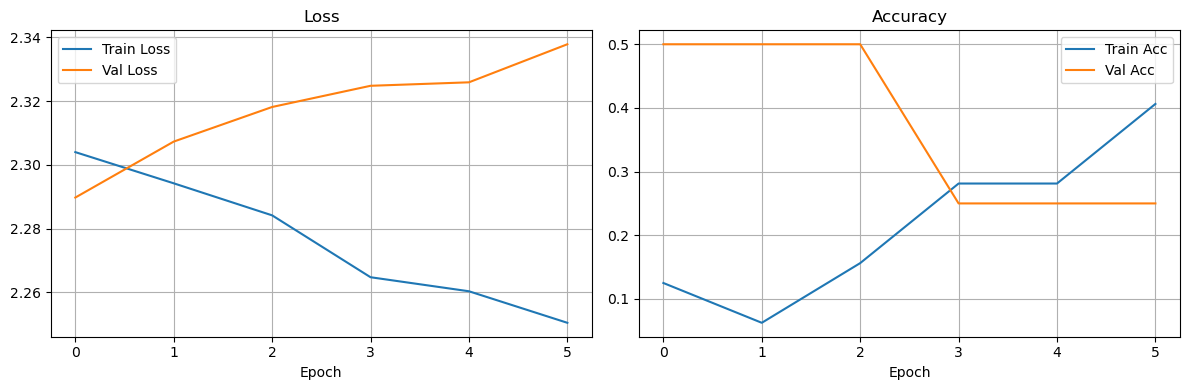

In [ ]:
train_losses, val_losses, train_accs, val_accs = train_mnist(
    model, X_train, y_train, X_val, y_val, 
    criterion, optimizer, epochs=30, batch_size=128
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()